# Progressive refinement: from rough fit to atomic coordinates

This is the next tutorial after `simple_refinement_tutorial.ipynb`. It uses a deliberately imperfect starting model and shows why refinement is normally done in levels:

1. scale and background;
2. zero shift, peak profile, and lattice;
3. atomic coordinates;
4. a joint polish.

You will see the fit improve at each level, inspect the loss curve, and see exactly how the atoms and unit cell moved.


## 1. Load a deliberately imperfect model and the pattern

The measured pattern was generated from the bundled reference structure. We start from `model-b.cif`, where the oxygen positions are shifted. The refinement receives only the starting model and pattern; the reference structure is loaded solely so this teaching example can show whether coordinates moved in the right direction.


In [1]:
from importlib.resources import files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from pymatgen.core import Structure

from braggcalculator import (
    DiffractionDataset,
    OptimizationStage,
    RefinementPolicy,
    RefinementSession,
    refined_structure_from_candidate,
)

EXAMPLE = Path(str(files("braggcalculator") / "tutorial_data"))
STARTING_MODEL = EXAMPLE / "model-b.cif"
XY_FILE = EXAMPLE / "pattern.xye"
WAVELENGTH_ANGSTROM = 1.5406

starting_model = Structure.from_file(STARTING_MODEL)
data = DiffractionDataset.from_xye(
    XY_FILE, wavelength=WAVELENGTH_ANGSTROM, radiation="xray"
)

# Used only to evaluate this synthetic teaching example; not passed to refinement.
known_reference = Structure.from_file(EXAMPLE / "model-a.cif")

print("Starting model:", STARTING_MODEL.name, starting_model.composition.reduced_formula)
print("Pattern:", XY_FILE.name, f"({len(data.coordinate)} points)")


Starting model: model-b.cif NaSiO2
Pattern: pattern.xye (801 points)


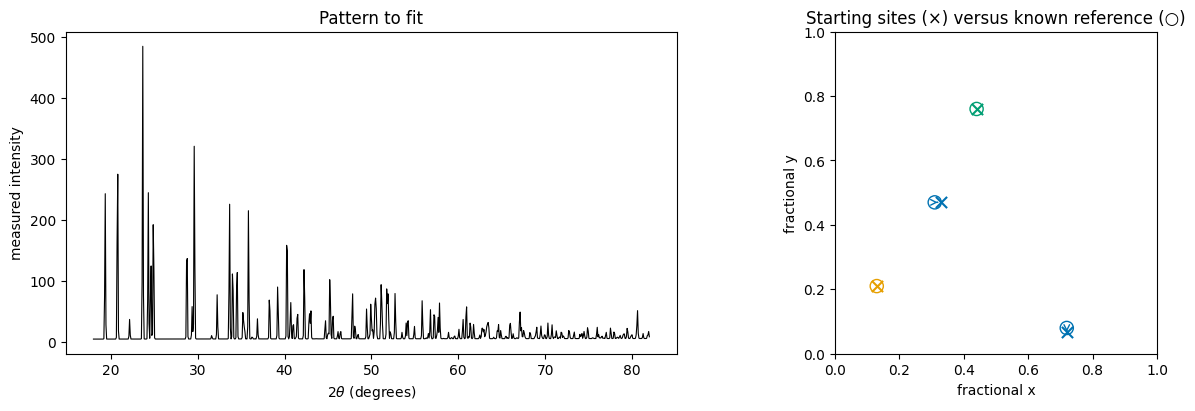

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(data.coordinate, data.intensity, color="black", linewidth=0.8)
axes[0].set(
    xlabel=r"$2\theta$ (degrees)", ylabel="measured intensity",
    title="Pattern to fit",
)
colors = {"Na": "#009E73", "Si": "#E69F00", "O": "#0072B2"}
for start, target in zip(starting_model, known_reference):
    color = colors.get(start.species_string, "0.4")
    axes[1].scatter(*target.frac_coords[:2], marker="o", facecolors="none",
                    edgecolors=color, s=90)
    axes[1].scatter(*start.frac_coords[:2], marker="x", color=color, s=65)
    axes[1].annotate("", xy=start.frac_coords[:2], xytext=target.frac_coords[:2],
                     arrowprops={"arrowstyle": "->", "color": color, "lw": 1})
axes[1].set(
    xlabel="fractional x", ylabel="fractional y", xlim=(0, 1), ylim=(0, 1),
    aspect="equal", title="Starting sites (×) versus known reference (○)",
)
plt.show()


## 2. Define four refinement levels

Each level includes the previous levels. This makes the effect of releasing a new parameter family visible. Atomic coordinates receive a restraint so they cannot wander freely while trying to imitate background or peak-shape errors.

| Level | Parameters allowed to change | Why now? |
|---|---|---|
| 1 | scale, background | Put calculated and measured intensities on the same baseline |
| 2 | zero shift, profile, lattice | Align peak positions and widths |
| 3 | atomic coordinates | Improve relative peak intensities after positions/shapes are reasonable |
| 4 | all above together | Remove small compromises between parameter groups |


In [3]:
stages = (
    OptimizationStage(
        "scale/background", ("scale", "background"), 25, 0.025
    ),
    OptimizationStage(
        "calibration/profile/lattice",
        ("zero_shift", "profile", "lattice"), 35, 0.008,
    ),
    OptimizationStage(
        "atomic coordinates", ("coordinates",), 35, 0.004
    ),
    OptimizationStage(
        "joint polish",
        ("scale", "background", "zero_shift", "profile",
         "lattice", "coordinates"),
        45, 0.002,
    ),
)

policies = {
    "1 — scale/background": RefinementPolicy(
        background_degree=1, refine_lattice=False, diagnostic_points=0,
        stages=stages[:1],
    ),
    "2 — profile/lattice": RefinementPolicy(
        background_degree=1, refine_lattice=True, diagnostic_points=0,
        stages=stages[:2],
    ),
    "3 — coordinates": RefinementPolicy(
        background_degree=1, refine_lattice=True, refine_coordinates=True,
        coordinate_restraint=0.05, diagnostic_points=0, stages=stages[:3],
    ),
    "4 — joint polish": RefinementPolicy(
        background_degree=1, refine_lattice=True, refine_coordinates=True,
        coordinate_restraint=0.05, diagnostic_points=32, stages=stages,
    ),
}

display([
    {"level": name, "optimizer steps": sum(stage.steps for stage in policy.stages)}
    for name, policy in policies.items()
])


[{'level': '1 — scale/background', 'optimizer steps': 25},
 {'level': '2 — profile/lattice', 'optimizer steps': 60},
 {'level': '3 — coordinates', 'optimizer steps': 95},
 {'level': '4 — joint polish', 'optimizer steps': 140}]

## 3. Run every level

For clarity, each level starts again from the same imperfect CIF. This costs a little more computation, but makes the comparison fair and easy to understand.


In [4]:
fits = {}
for level, policy in policies.items():
    session = RefinementSession(data, [starting_model], names=["candidate"])
    fits[level] = session.run(policy).candidates[0]
    print(f"{level}: Rwp = {100 * fits[level].r_wp:.2f}%")

final_fit = fits["4 — joint polish"]


1 — scale/background: Rwp = 18.52%
2 — profile/lattice: Rwp = 13.01%
3 — coordinates: Rwp = 11.60%
4 — joint polish: Rwp = 9.19%


## 4. See what each level accomplished

The bar chart shows the overall improvement. The profile plot shows where the curves change. The remaining residual is `measured - calculated`.


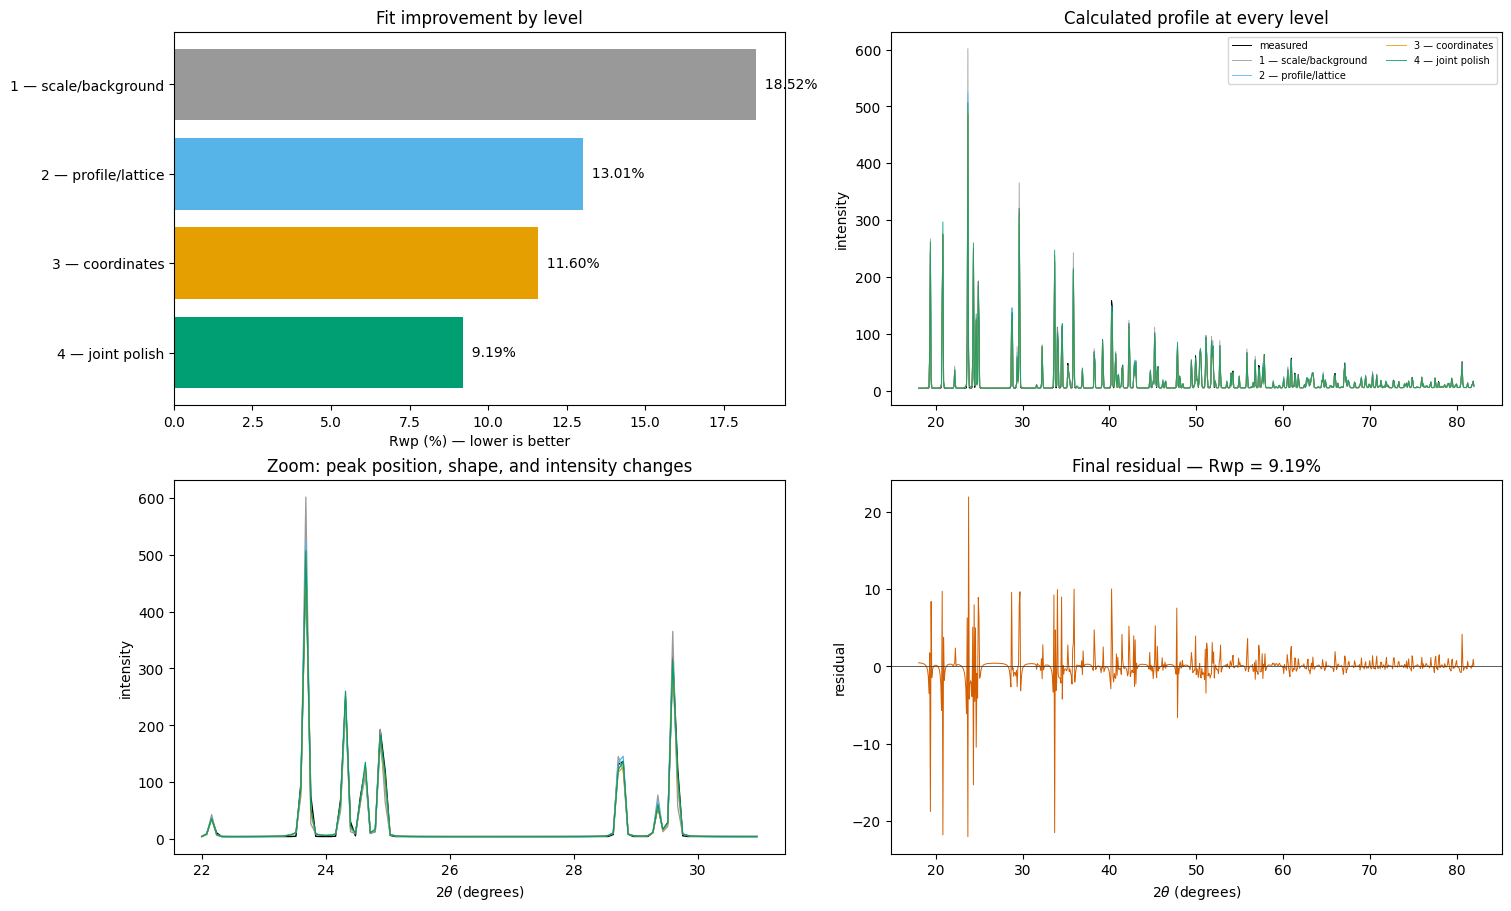

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
levels = list(fits)
rwp_percent = [100 * fits[level].r_wp for level in levels]
bars = axes[0, 0].barh(np.arange(len(levels)), rwp_percent,
                         color=["#999999", "#56B4E9", "#E69F00", "#009E73"])
axes[0, 0].set(yticks=np.arange(len(levels)), yticklabels=levels,
                   xlabel="Rwp (%) — lower is better", title="Fit improvement by level")
axes[0, 0].invert_yaxis()
for bar, value in zip(bars, rwp_percent):
    axes[0, 0].text(value, bar.get_y()+bar.get_height()/2, f"  {value:.2f}%", va="center")

axes[0, 1].plot(data.coordinate, data.intensity, color="black", lw=0.7, label="measured")
for level, color in zip(levels, ["#999999", "#56B4E9", "#E69F00", "#009E73"]):
    axes[0, 1].plot(data.coordinate, fits[level].calculated, color=color, lw=0.7,
                    alpha=0.85, label=level)
axes[0, 1].set(ylabel="intensity", title="Calculated profile at every level")
axes[0, 1].legend(fontsize=7, ncol=2)

zoom = (data.coordinate >= 22) & (data.coordinate <= 31)
axes[1, 0].plot(data.coordinate[zoom], data.intensity[zoom], color="black", lw=1,
                   label="measured")
for level, color in zip(levels, ["#999999", "#56B4E9", "#E69F00", "#009E73"]):
    axes[1, 0].plot(data.coordinate[zoom], fits[level].calculated[zoom], color=color, lw=0.9)
axes[1, 0].set(xlabel=r"$2\theta$ (degrees)", ylabel="intensity",
                   title="Zoom: peak position, shape, and intensity changes")

axes[1, 1].plot(data.coordinate, final_fit.residual, color="#D55E00", lw=0.7)
axes[1, 1].axhline(0, color="0.25", lw=0.6)
axes[1, 1].set(xlabel=r"$2\theta$ (degrees)", ylabel="residual",
                   title=f"Final residual — Rwp = {100 * final_fit.r_wp:.2f}%")
plt.show()


## 5. Read the loss curve

The loss is the number the optimizer tries to reduce. Each colored segment is one refinement stage. A downward segment means that stage found a better fit. A jump or flat segment is a reason to inspect the policy, learning rate, starting model, or parameter correlations rather than simply adding more steps.


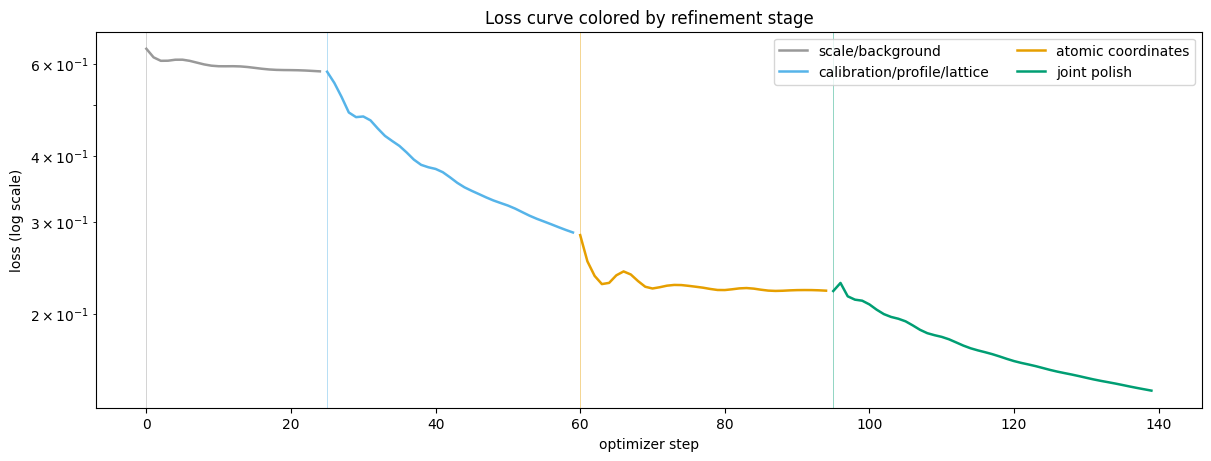

[{'stage': np.str_('scale/background'),
  'first loss': np.float64(0.6405934951204086),
  'last loss': np.float64(0.5800755180781338)},
 {'stage': np.str_('calibration/profile/lattice'),
  'first loss': np.float64(0.5791500720166226),
  'last loss': np.float64(0.2858798153433997)},
 {'stage': np.str_('atomic coordinates'),
  'first loss': np.float64(0.28259522104500273),
  'last loss': np.float64(0.22140591524790323)},
 {'stage': np.str_('joint polish'),
  'first loss': np.float64(0.22105110075413661),
  'last loss': np.float64(0.1427404259823701)}]

In [6]:
loss = np.asarray(final_fit.loss_history)
stage_names = np.asarray(final_fit.stage_history)
stage_order = list(dict.fromkeys(stage_names))
stage_colors = ["#999999", "#56B4E9", "#E69F00", "#009E73"]

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
for name, color in zip(stage_order, stage_colors):
    indices = np.flatnonzero(stage_names == name)
    ax.semilogy(indices, loss[indices], color=color, linewidth=1.8, label=name)
    ax.axvline(indices[0], color=color, linewidth=0.6, alpha=0.5)
ax.set(xlabel="optimizer step", ylabel="loss (log scale)",
       title="Loss curve colored by refinement stage")
ax.legend(ncol=2)
plt.show()

display([
    {
        "stage": name,
        "first loss": loss[np.flatnonzero(stage_names == name)[0]],
        "last loss": loss[np.flatnonzero(stage_names == name)[-1]],
    }
    for name in stage_order
])


## 6. See how the atoms moved

The arrows below run from the starting positions to the refined positions. Because this is synthetic, we can also calculate distance from the known reference before and after refinement. A real experiment does not provide that final truth column.

Notice that coordinate refinement can improve the deliberately shifted oxygens while also moving atoms that started correctly. That is exactly why coordinate restraints, correlations, and chemical judgment matter.


[{'site': '0: Na',
  'movement (angstrom)': np.float64(0.04955008907927473),
  'starting error vs known reference (angstrom)': np.float64(0.0),
  'refined error vs known reference (angstrom)': np.float64(0.04955008907927473)},
 {'site': '1: Si',
  'movement (angstrom)': np.float64(0.04988887644887368),
  'starting error vs known reference (angstrom)': np.float64(0.0),
  'refined error vs known reference (angstrom)': np.float64(0.04988887644887368)},
 {'site': '2: O',
  'movement (angstrom)': np.float64(0.05114344322380294),
  'starting error vs known reference (angstrom)': np.float64(0.08640000000000007),
  'refined error vs known reference (angstrom)': np.float64(0.04328276756030602)},
 {'site': '3: O',
  'movement (angstrom)': np.float64(0.0745454536589497),
  'starting error vs known reference (angstrom)': np.float64(0.07370650750293573),
  'refined error vs known reference (angstrom)': np.float64(0.04214849845077478)}]

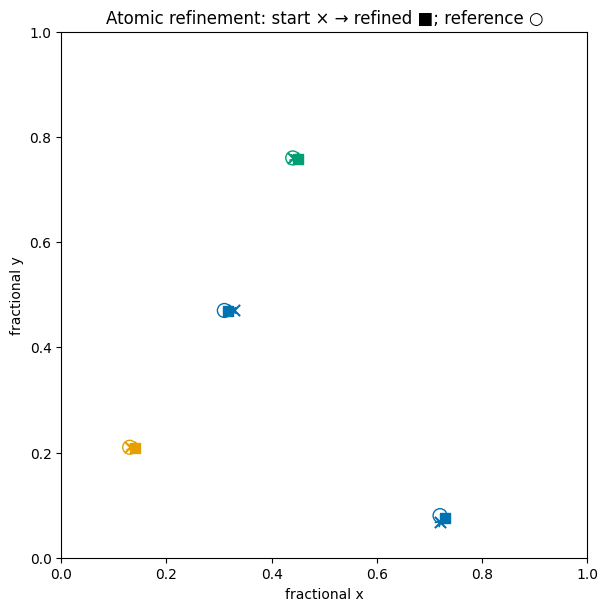

In [7]:
refined_model = refined_structure_from_candidate(final_fit, data)

def wrapped_fractional_delta(first, second):
    return (np.asarray(first) - np.asarray(second) + 0.5) % 1.0 - 0.5

coordinate_rows = []
for index, (start, refined, target) in enumerate(
    zip(starting_model, refined_model, known_reference)
):
    start_error = np.linalg.norm(
        starting_model.lattice.get_cartesian_coords(
            wrapped_fractional_delta(start.frac_coords, target.frac_coords)
        )
    )
    refined_error = np.linalg.norm(
        refined_model.lattice.get_cartesian_coords(
            wrapped_fractional_delta(refined.frac_coords, target.frac_coords)
        )
    )
    movement = np.linalg.norm(
        refined_model.lattice.get_cartesian_coords(
            wrapped_fractional_delta(refined.frac_coords, start.frac_coords)
        )
    )
    coordinate_rows.append({
        "site": f"{index}: {start.species_string}",
        "movement (angstrom)": movement,
        "starting error vs known reference (angstrom)": start_error,
        "refined error vs known reference (angstrom)": refined_error,
    })
display(coordinate_rows)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
for start, refined, target in zip(starting_model, refined_model, known_reference):
    color = colors.get(start.species_string, "0.4")
    ax.scatter(*target.frac_coords[:2], marker="o", facecolors="none",
               edgecolors=color, s=100)
    ax.scatter(*start.frac_coords[:2], marker="x", color=color, s=65)
    ax.scatter(*refined.frac_coords[:2], marker="s", color=color, s=48)
    ax.annotate("", xy=refined.frac_coords[:2], xytext=start.frac_coords[:2],
                arrowprops={"arrowstyle": "->", "color": color, "lw": 1.2})
ax.set(xlabel="fractional x", ylabel="fractional y", xlim=(0, 1), ylim=(0, 1),
       aspect="equal", title="Atomic refinement: start × → refined ■; reference ○")
plt.show()


## 7. See how the unit cell and calibration moved

Lengths are in ångström and angles are in degrees. Small changes can noticeably improve peak positions across a long pattern.


In [8]:
physical = final_fit.physical_parameters
starting_cell = {
    "a": starting_model.lattice.a, "b": starting_model.lattice.b,
    "c": starting_model.lattice.c, "alpha": starting_model.lattice.alpha,
    "beta": starting_model.lattice.beta, "gamma": starting_model.lattice.gamma,
}
display([
    {"parameter": name, "starting": starting_cell[name],
     "refined": physical["cell_parameters"][name]}
    for name in ("a", "b", "c", "alpha", "beta", "gamma")
])
print(f"Refined zero shift: {physical['zero_shift']:.5f} degrees")
print(f"Final Rwp: {100 * final_fit.r_wp:.2f}%")


[{'parameter': 'a', 'starting': 4.8, 'refined': 4.800422162638739},
 {'parameter': 'b',
  'starting': 5.400000000000001,
  'refined': 5.4005172113930895},
 {'parameter': 'c', 'starting': 6.2, 'refined': 6.200777174466832},
 {'parameter': 'alpha', 'starting': 79.0, 'refined': 79.00035082490555},
 {'parameter': 'beta', 'starting': 84.0, 'refined': 83.99983789651515},
 {'parameter': 'gamma', 'starting': 73.0, 'refined': 72.99628500781566}]

Refined zero shift: 0.00935 degrees
Final Rwp: 9.19%


## 8. Other refinement types available

The example above demonstrates the parameter families normally released first. BraggCalculator also supports the following, but they should be enabled only when the chemistry and information content justify them:

| Refinement type | Policy/API switch | Use it when |
|---|---|---|
| Atomic coordinates | `refine_coordinates=True` | Relative intensities support positional changes |
| Site composition | `occupancy_mode="composition"` | Species share a fully occupied site |
| Vacancies | `occupancy_mode="vacancy"` | Total site occupancy may be below one |
| Isotropic displacement | `refine_b_iso=True` | Data support a positive orbit-shared Biso |
| Anisotropic displacement | `refine_u_aniso=True` | High-quality data support a tensor; do not combine blindly with Biso |
| Rigid molecules/motifs | `rigid_bodies=[...]` | Internal geometry should stay fixed while position/orientation changes |
| Phase fractions | `PhaseMixtureSession` | More than one crystalline phase contributes |
| Bond/distance restraints | `structural_restraints={...}` | Chemistry must stabilize weak diffraction directions |

A useful rule is: **release the smallest parameter group that explains a visible, supported residual, then check whether the loss, held-out fit, parameter correlations, and chemistry all improve.** Do not simply turn every switch on.


## Done

You have now performed and compared four levels of refinement, inspected the loss curve, and measured both lattice and atomic-coordinate changes. The full characterization notebook goes further into model comparison, identifiability, and experiment design.
